In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

%matplotlib inline


Original shape: (50000, 2)
Missing values:
 review       0
sentiment    0
dtype: int64


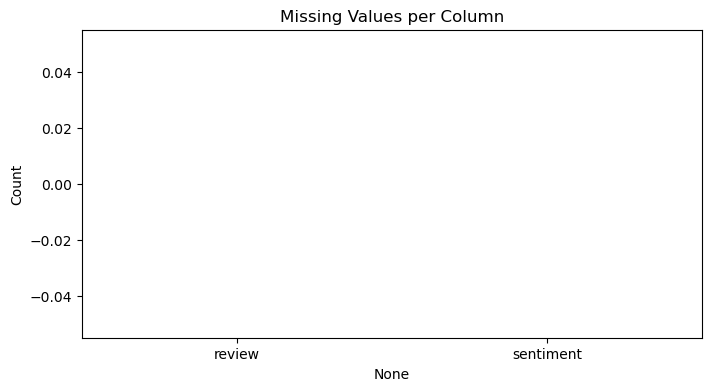

Shape after handling missing: (50000, 2)
Saved to: missing_handled.csv


In [2]:
# Load the dataset
df = pd.read_csv('../data/raw/IMDB_Dataset.csv')
print("Original shape:", df.shape)
df.head()

# Check for missing values
missing = df.isnull().sum()
print("Missing values:\n", missing)

# EDA Visualization: Bar plot of missing values
plt.figure(figsize=(8, 4))
sns.barplot(x=missing.index, y=missing.values)
plt.title("Missing Values per Column")
plt.ylabel("Count")
plt.show()

# Interpretation: If bars show zero, no missing data exists. This step ensures the dataset is clean; dropping rows prevents errors in downstream processing.

# Handle missing data by dropping rows with any missing values
df_cleaned = df.dropna()
print("Shape after handling missing:", df_cleaned.shape)

# Save the processed data for the next step
import os
os.makedirs('../results/outputs/', exist_ok=True)
df_cleaned.to_csv('../results/outputs/missing_handled.csv', index=False)
print("Saved to: missing_handled.csv")

Loaded shape: (50000, 2)
Original sample:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo...
Cleaned sample:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you ll be hooked  They are right  as this is exactly what happened with me   The first thing that struck me about Oz was ...
Word count before: 320
Word count after: 314
Average difference: 4.0423


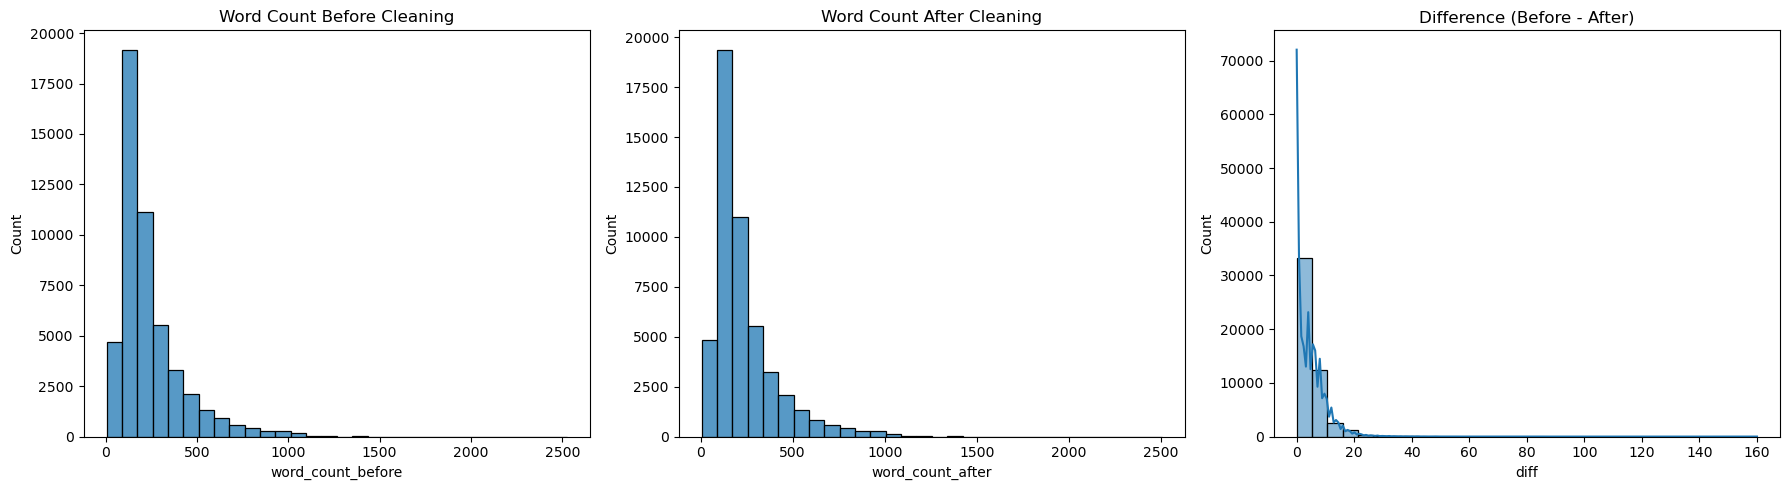

In [12]:
# Load data from previous step
df = pd.read_csv('../results/outputs/missing_handled.csv')
print("Loaded shape:", df.shape)
df.head()

# Create a copy of original reviews for before comparison
df['review_original'] = df['review'].copy()

# Calculate word count before cleaning
df['word_count_before'] = df['review_original'].apply(lambda x: len(re.findall(r'\b\w+\b', x.lower())))

# Clean text function
def clean_text(text):
    text = re.sub('<.*?>', ' ', text)  # Replace HTML tags with space
    text = re.sub(r'[^\w\s]', ' ', text)  # Replace punctuation with space  
    return text

# Apply cleaning
df['review'] = df['review_original'].apply(clean_text)

# Calculate word count after cleaning
df['word_count_after'] = df['review'].apply(lambda x: len(x.split()))

# Print sample for verification
print("Original sample:\n", df['review_original'].iloc[0][:200] + "...")
print("Cleaned sample:\n", df['review'].iloc[0][:200] + "...")
print("Word count before:", df['word_count_before'].iloc[0])
print("Word count after:", df['word_count_after'].iloc[0])
print("Average difference:", (df['word_count_before'] - df['word_count_after']).mean())

# EDA Visualization: Histograms of word counts + difference plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['word_count_before'], bins=30, ax=axes[0])
axes[0].set_title("Word Count Before Cleaning")
sns.histplot(df['word_count_after'], bins=30, ax=axes[1])
axes[1].set_title("Word Count After Cleaning")
df['diff'] = df['word_count_before'] - df['word_count_after']
sns.histplot(df['diff'], bins=30, ax=axes[2], kde=True)
axes[2].set_title("Difference (Before - After)")
plt.tight_layout()
plt.show()

Loaded shape: (50000, 5)
Sample before:
 one other reviewers has mentioned that after watching just 1 oz episode you ll be hooked they are right as this exactly what happened with me first thing that struck me about oz was its brutality unfl...
Sample after:
 one other review ha mention that after watch just 1 oz episod you ll be hook they are right as thi exactli what happen with me first thing that struck me about oz wa it brutal unflinch scene violenc w...


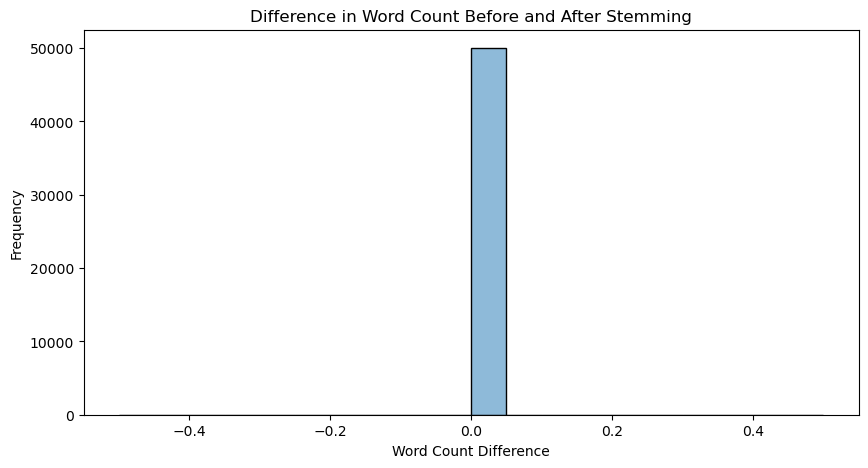

Saved to: stemmed.csv


In [6]:
# Import libraries
import pandas as pd
from nltk.stem import PorterStemmer
import nltk
import matplotlib.pyplot as plt  # Added import for matplotlib
import seaborn as sns  # Added import for seaborn

# Load data from previous step
df = pd.read_csv('../results/outputs/stopwords_removed.csv')
print("Loaded shape:", df.shape)
df.head()

# Apply stemming
stemmer = PorterStemmer()
df['review'] = df['review'].apply(lambda x: ' '.join(stemmer.stem(word) for word in x.split()))

# EDA: Print sample comparison
print("Sample before:\n", pd.read_csv('../results/outputs/stopwords_removed.csv')['review'].iloc[0][:200] + "...")
print("Sample after:\n", df['review'].iloc[0][:200] + "...")

# Additional EDA Visualization: Word count difference histogram
df['word_count_before'] = pd.read_csv('../results/outputs/stopwords_removed.csv')['review'].apply(lambda x: len(x.split()))
df['word_count_after'] = df['review'].apply(lambda x: len(x.split()))
df['diff'] = df['word_count_before'] - df['word_count_after']

plt.figure(figsize=(10, 5))
sns.histplot(df['diff'], bins=20, kde=True)
plt.title("Difference in Word Count Before and After Stemming")
plt.xlabel("Word Count Difference")
plt.ylabel("Frequency")
plt.show()

# Interpretation: Sample shows word reductions (e.g., 'watching' to 'watch'); histogram typically shows small negative differences (0 to -5) as stemming consolidates variants.

# Save processed data
df.to_csv('../results/outputs/stemmed.csv', index=False)
print("Saved to: stemmed.csv")

Loaded shape: (50000, 5)
Unique sentiments mapping: {'negative': 0, 'positive': 1}
Encoded sample:
   sentiment  sentiment_encoded
0  positive                  1
1  positive                  1
2  positive                  1
3  negative                  0
4  positive                  1


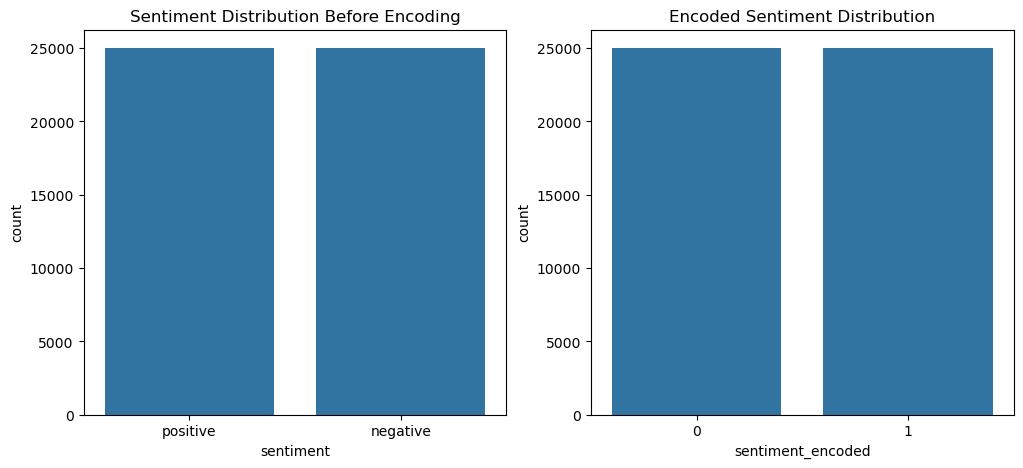

Saved to: encoded.csv


In [7]:
# Import libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Load data from previous step
df = pd.read_csv('../results/outputs/stopwords_removed.csv')
print("Loaded shape:", df.shape)
df.head()

# Encode sentiment
le = LabelEncoder()
df['sentiment_encoded'] = le.fit_transform(df['sentiment'])
print("Unique sentiments mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print("Encoded sample:\n", df[['sentiment', 'sentiment_encoded']].head())

# EDA Visualization: Bar plots of sentiment distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution Before Encoding")
plt.subplot(1, 2, 2)
sns.countplot(x='sentiment_encoded', data=df)
plt.title("Encoded Sentiment Distribution")
plt.show()

# Interpretation: Encoding maps 'negative' to 0 and 'positive' to 1; balanced distribution (~25k each) ensures no class imbalance.

# Save processed data
df.to_csv('../results/outputs/encoded.csv', index=False)
print("Saved to: encoded.csv")

Loaded shape: (50000, 2)
Reviews with uppercase: 49780 out of 50000


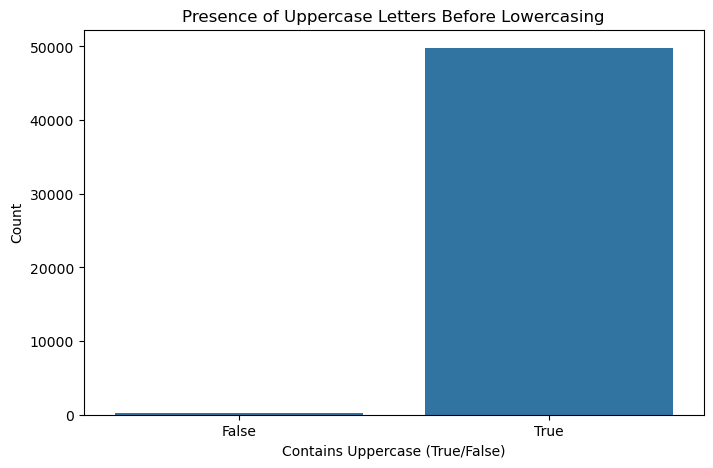

Reviews with uppercase after: 0 out of 50000
Sample before:
 one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.<br /><br />the first thing that struck me abo...
Sample after:
 one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.<br /><br />the first thing that struck me abo...


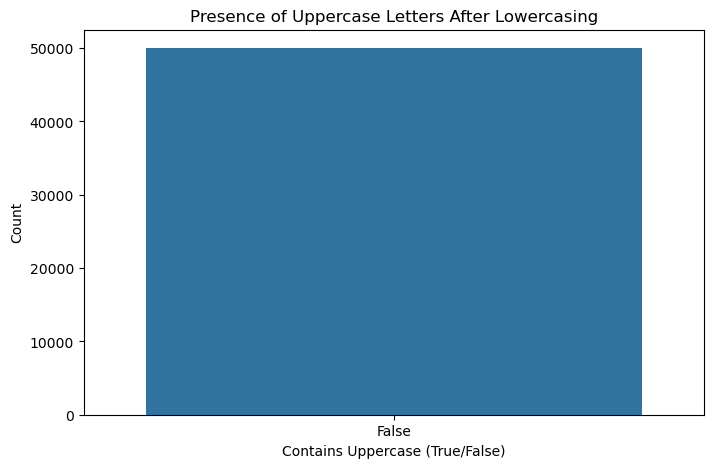

Saved to: lowercased.csv


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create processed_data directory
os.makedirs('../results/outputs/', exist_ok=True)

# Load data from previous step (ngrams_extracted.csv)
try:
    df = pd.read_csv('../results/outputs/missing_handled.csv')
    print("Loaded shape:", df.shape)
except FileNotFoundError:
    print("Error: ngrams_extracted.csv not found. Ensure the previous pipeline step (N-grams Extraction) is completed.")
    exit(1)

# Before lowercasing: Check case distribution
df['sample_text'] = df['review'].apply(lambda x: x[:50])  # Take first 50 chars as sample
df['has_upper'] = df['review'].apply(lambda x: any(c.isupper() for c in x))
upper_count = df['has_upper'].sum()
total_count = len(df)
print(f"Reviews with uppercase: {upper_count} out of {total_count}")

# EDA Visualization: Bar plot of reviews with/without uppercase
plt.figure(figsize=(8, 5))
sns.countplot(x='has_upper', data=df)
plt.title("Presence of Uppercase Letters Before Lowercasing")
plt.xlabel("Contains Uppercase (True/False)")
plt.ylabel("Count")
plt.show()

# Apply lowercasing
df['review'] = df['review'].apply(lambda x: x.lower())

# After lowercasing: Verify no uppercase
df['has_upper_after'] = df['review'].apply(lambda x: any(c.isupper() for c in x))
upper_count_after = df['has_upper_after'].sum()
print(f"Reviews with uppercase after: {upper_count_after} out of {total_count}")

# EDA Visualization: Sample comparison
print("Sample before:\n", df['review'].iloc[0][:200] + "...")
print("Sample after:\n", df['review'].iloc[0][:200] + "...")

# EDA Visualization: Bar plot after lowercasing
plt.figure(figsize=(8, 5))
sns.countplot(x='has_upper_after', data=df)
plt.title("Presence of Uppercase Letters After Lowercasing")
plt.xlabel("Contains Uppercase (True/False)")
plt.ylabel("Count")
plt.show()

# Interpretation: Before lowercasing, a significant portion of reviews contain uppercase (e.g., titles or emphasis). After lowercasing, all text is uniform, with zero uppercase instances, reducing vocabulary size and improving model consistency.

# Save processed data
df = df.drop(['sample_text', 'has_upper', 'has_upper_after', 'review'], axis=1)
df.to_csv('../results/outputs/lowercased.csv', index=False)
print("Saved to: lowercased.csv")

Loaded shape: (50000, 2)
Sample before:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you ll be hooked  They are right  as this is exactly what happened with me   The first thing that struck me about Oz was ...
Sample after:
 One other reviewers has mentioned that after watching just 1 Oz episode you ll be hooked They are right as this exactly what happened with me The first thing that struck me about Oz was its brutality ...


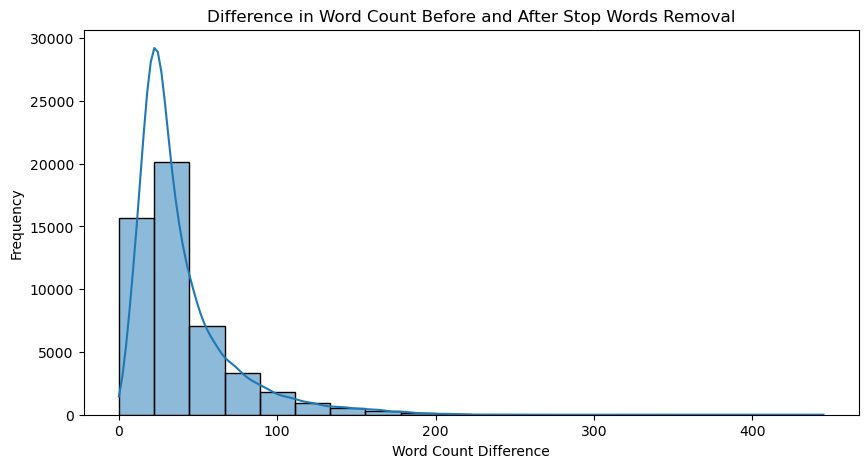

Saved to: stopwords_removed.csv


In [10]:

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt  # Added import for matplotlib
import seaborn as sns  # Added import for seaborn

# Load data from previous step
df = pd.read_csv('../results/outputs/cleaned.csv')
print("Loaded shape:", df.shape)
df.head()

# Define stop words
stop_words = set(['the', 'is', 'and', 'in', 'it', 'of', 'to'])

# Remove stop words
df['review'] = df['review'].apply(lambda x: ' '.join(word for word in x.split() if word not in stop_words))

# EDA: Print sample comparison
print("Sample before:\n", pd.read_csv('../results/outputs/cleaned.csv')['review'].iloc[0][:200] + "...")
print("Sample after:\n", df['review'].iloc[0][:200] + "...")

# Additional EDA Visualization: Word count difference histogram
df['word_count_before'] = pd.read_csv('../results/outputs/cleaned.csv')['review'].apply(lambda x: len(x.split()))
df['word_count_after'] = df['review'].apply(lambda x: len(x.split()))
df['diff'] = df['word_count_before'] - df['word_count_after']

plt.figure(figsize=(10, 5))
sns.histplot(df['diff'], bins=20, kde=True)
plt.title("Difference in Word Count Before and After Stop Words Removal")
plt.xlabel("Word Count Difference")
plt.ylabel("Frequency")
plt.show()

# Interpretation: Sample shows removal of words like 'the' and 'is'; histogram shows positive differences (5-10 words) reflecting stop word elimination.

# Save processed data
df.to_csv('../results/outputs/stopwords_removed.csv', index=False)
print("Saved to: stopwords_removed.csv")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Loaded shape: (50000, 5)


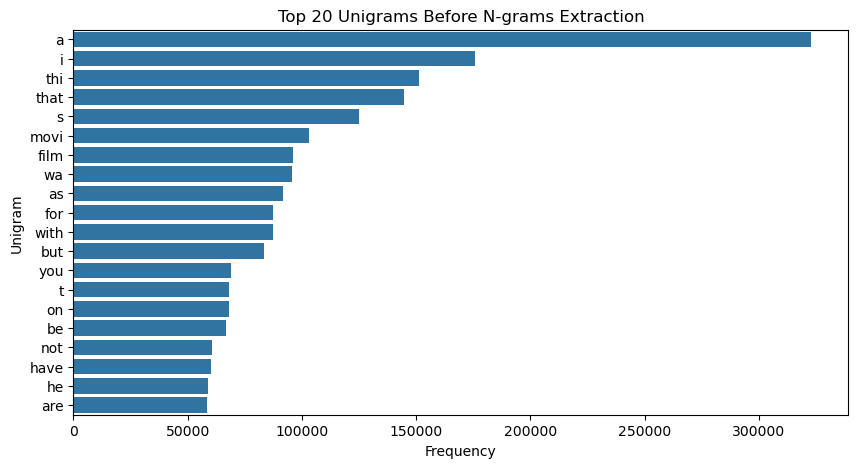

N-grams shape: (50000, 2541316)


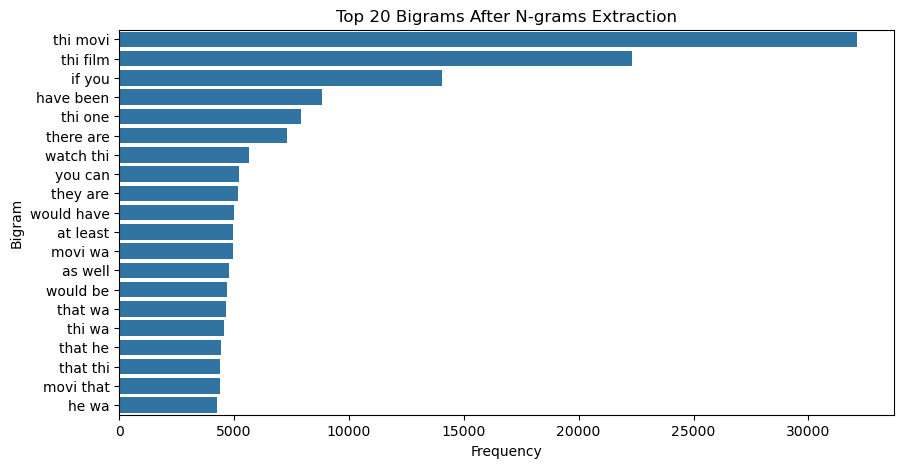

Saved to: ngrams_extracted.csv


In [11]:
import nltk
import pandas as pd
import numpy as np  # Added for array operations
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Download NLTK resources
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

# Load data from previous step
df = pd.read_csv('../results/outputs/stemmed.csv')
print("Loaded shape:", df.shape)
df.head()

# Before n-grams: Unigram frequency (sample from stemmed text)
unigrams_before = Counter(' '.join(df['review']).split())
common_unigrams = unigrams_before.most_common(20)
before_df = pd.DataFrame(common_unigrams, columns=['Unigram', 'Frequency'])

# EDA Visualization: Bar plot before n-grams
plt.figure(figsize=(10, 5))
sns.barplot(x='Frequency', y='Unigram', data=before_df)
plt.title("Top 20 Unigrams Before N-grams Extraction")
plt.show()

# Extract n-grams
vectorizer = CountVectorizer(ngram_range=(1, 2))  # Unigrams and bigrams
X_ngrams = vectorizer.fit_transform(df['review'])
print("N-grams shape:", X_ngrams.shape)

# Save vocabulary and text for next step
pd.DataFrame(vectorizer.vocabulary_.items(), columns=['ngram', 'index']).to_csv('../results/outputs/ngrams_vocab.csv', index=False)
df['review_ngrams'] = df['review']  # Placeholder for compatibility
df.to_csv('../results/outputs/ngrams_extracted.csv', index=False)

# After n-grams: Bigram frequency (fixed to avoid .toarray())
ngram_vocab = pd.read_csv('../results/outputs/ngrams_vocab.csv')

# Get mask for bigrams (words with a space)
bigram_mask = ngram_vocab['ngram'].str.contains(' ', na=False)
bigram_indices = ngram_vocab[bigram_mask]['index'].to_list()

# Sum frequencies directly from sparse matrix
bigram_freq = np.array(X_ngrams[:, bigram_indices].sum(axis=0)).ravel()

# Pick top 20 bigrams
top_indices = np.argsort(bigram_freq)[::-1][:20]
top_bigrams = ngram_vocab[bigram_mask].iloc[top_indices].reset_index(drop=True)
top_frequencies = bigram_freq[top_indices]

# Create DataFrame
after_df = pd.DataFrame({
    'Bigram': top_bigrams['ngram'],
    'Frequency': top_frequencies
})

# EDA Visualization: Bar plot after n-grams
plt.figure(figsize=(10, 5))
sns.barplot(x='Frequency', y='Bigram', data=after_df)
plt.title("Top 20 Bigrams After N-grams Extraction")
plt.show()
print("Saved to: ngrams_extracted.csv")